In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
courses=pd.read_csv('/content/udemy_courses-raw.csv')

In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   course_id            3678 non-null   int64  
 1   course_title         3678 non-null   object 
 2   url                  3678 non-null   object 
 3   is_paid              3678 non-null   bool   
 4   price                3678 non-null   int64  
 5   num_subscribers      3678 non-null   int64  
 6   num_reviews          3678 non-null   int64  
 7   num_lectures         3678 non-null   int64  
 8   level                3678 non-null   object 
 9   content_duration     3678 non-null   float64
 10  published_timestamp  3678 non-null   object 
 11  subject              3678 non-null   object 
dtypes: bool(1), float64(1), int64(5), object(5)
memory usage: 319.8+ KB


In [ ]:
courses.describe()

,course_id,price,num_subscribers,num_reviews,num_lectures,content_duration
count,3.678000e+03,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000
mean,6.759720e+05,66.049483,3197.150625,156.259108,40.108755,4.094517
std,3.432732e+05,61.005755,9504.117010,935.452044,50.383346,6.053840
min,8.324000e+03,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.076925e+05,20.000000,111.000000,4.000000,15.000000,1.000000
50%,6.879170e+05,45.000000,911.500000,18.000000,25.000000,2.000000
75%,9.613555e+05,95.000000,2546.000000,67.000000,45.750000,4.500000
max,1.282064e+06,200.000000,268923.000000,27445.000000,779.000000,78.500000


# preprocessing

In [ ]:
courses.drop(['course_id','course_title','url','num_reviews'],axis=1,inplace=True)

In [ ]:
courses['published_timestamp'] = pd.to_datetime(courses['published_timestamp'])
courses['year'] = courses['published_timestamp'].dt.year
courses['month'] = courses['published_timestamp'].dt.month


In [ ]:
courses.head()

,is_paid,price,num_subscribers,num_lectures,level,content_duration,published_timestamp,subject,year,month
0,True,200,2147,51,All Levels,1.5,2017-01-18 20:58:58+00:00,Business Finance,2017,1
1,True,75,2792,274,All Levels,39.0,2017-03-09 16:34:20+00:00,Business Finance,2017,3
2,True,45,2174,51,Intermediate Level,2.5,2016-12-19 19:26:30+00:00,Business Finance,2016,12
3,True,95,2451,36,All Levels,3.0,2017-05-30 20:07:24+00:00,Business Finance,2017,5
4,True,200,1276,26,Intermediate Level,2.0,2016-12-13 14:57:18+00:00,Business Finance,2016,12


In [ ]:
courses.drop('published_timestamp',axis=1,inplace=True)

In [ ]:
courses['is_paid'].value_counts()

,count
is_paid,
True,3368
False,310


In [ ]:
courses['level'].value_counts()

,count
level,
All Levels,1929
Beginner Level,1270
Intermediate Level,421
Expert Level,58


# encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder,MinMaxScaler

encoder =OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(courses[['subject']])
print(encoded)

[[1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 ...
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]]


In [ ]:
encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['subject'])) #convert to dataframe
courses = pd.concat([courses.drop('subject', axis=1), encoded], axis=1)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

courses['Level'] = courses['level'].replace({
    'Beginner Level': 0,
    'Intermediate Level': 1,
    'Expert Level': 2,
    'All Levels': 3
})
courses.drop('level',axis=1,inplace=True)

/tmp/ipython-input-1235165177.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  courses['Level'] = courses['level'].replace({


In [ ]:
courses.head(20)

,is_paid,price,num_subscribers,num_lectures,content_duration,year,month,subject_Business Finance,subject_Graphic Design,subject_Musical Instruments,subject_Web Development,Level
0,True,200,2147,51,1.500000,2017,1,1.0,0.0,0.0,0.0,3
1,True,75,2792,274,39.000000,2017,3,1.0,0.0,0.0,0.0,3
2,True,45,2174,51,2.500000,2016,12,1.0,0.0,0.0,0.0,1
3,True,95,2451,36,3.000000,2017,5,1.0,0.0,0.0,0.0,3
4,True,200,1276,26,2.000000,2016,12,1.0,0.0,0.0,0.0,1
5,True,150,9221,25,3.000000,2014,5,1.0,0.0,0.0,0.0,3
6,True,65,1540,26,1.000000,2016,2,1.0,0.0,0.0,0.0,0
7,True,95,2917,23,2.500000,2015,1,1.0,0.0,0.0,0.0,3
8,True,195,5172,38,2.500000,2015,5,1.0,0.0,0.0,0.0,2
9,True,200,827,15,1.000000,2017,4,1.0,0.0,0.0,0.0,3


In [ ]:
courses['is_paid'] = courses['is_paid'].map({True: 1, False: 0})


In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   is_paid                      3678 non-null   int64  
 1   price                        3678 non-null   int64  
 2   num_subscribers              3678 non-null   int64  
 3   num_lectures                 3678 non-null   int64  
 4   content_duration             3678 non-null   float64
 5   year                         3678 non-null   int32  
 6   month                        3678 non-null   int32  
 7   subject_Business Finance     3678 non-null   float64
 8   subject_Graphic Design       3678 non-null   float64
 9   subject_Musical Instruments  3678 non-null   float64
 10  subject_Web Development      3678 non-null   float64
 11  Level                        3678 non-null   int64  
dtypes: float64(5), int32(2), int64(5)
memory usage: 316.2 KB


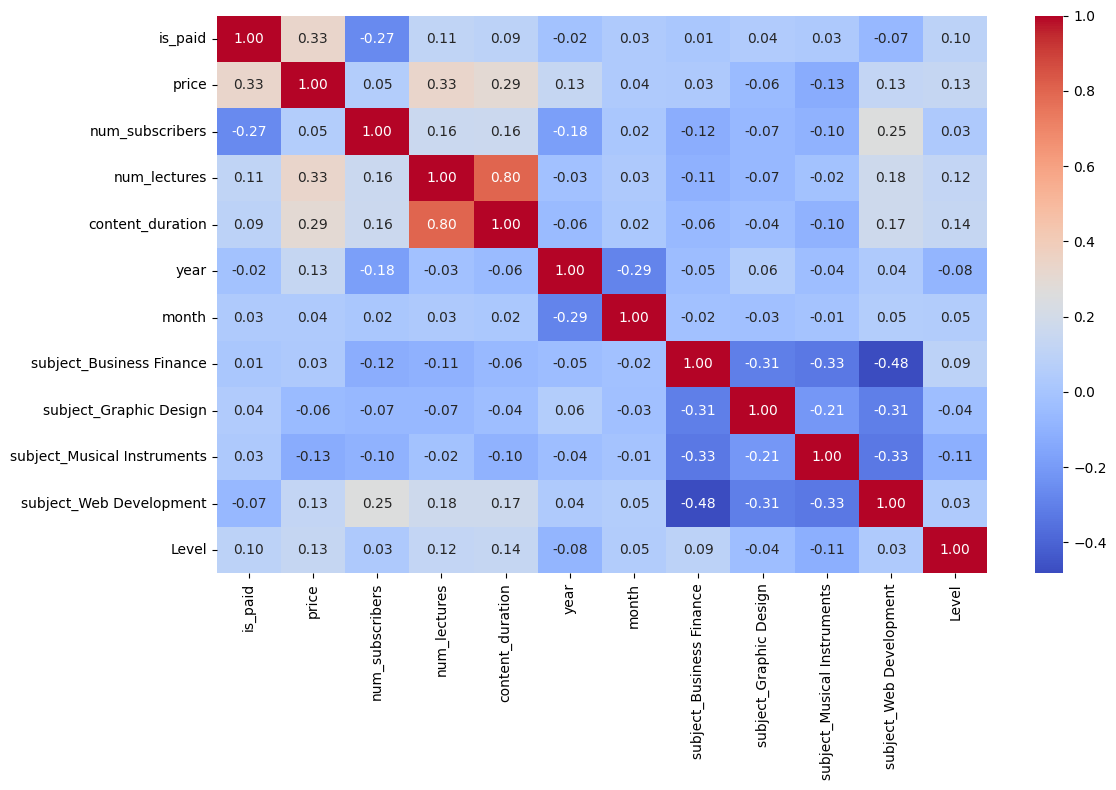

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr = courses.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})

#plt.xticks(rotation=40)
plt.tight_layout()

plt.show()


# outliers

In [ ]:
courses.describe()

,is_paid,price,num_subscribers,num_lectures,content_duration,year,month,subject_Business Finance,subject_Graphic Design,subject_Musical Instruments,subject_Web Development,Level
count,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000
mean,0.915715,66.049483,3197.150625,40.108755,4.094517,2015.431213,6.164220,0.324905,0.163948,0.184883,0.326264,1.719413
std,0.277852,61.005755,9504.117010,50.383346,6.053840,1.185317,3.380535,0.468403,0.370279,0.388255,0.468909,1.393527
min,0.000000,0.000000,0.000000,0.000000,0.000000,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,20.000000,111.000000,15.000000,1.000000,2015.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,45.000000,911.500000,25.000000,2.000000,2016.000000,6.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1.000000,95.000000,2546.000000,45.750000,4.500000,2016.000000,9.000000,1.000000,0.000000,0.000000,1.000000,3.000000
max,1.000000,200.000000,268923.000000,779.000000,78.500000,2017.000000,12.000000,1.000000,1.000000,1.000000,1.000000,3.000000


In [ ]:
# 0- explore for each column
import pandas as pd
df=courses[['price',	'num_subscribers',	'num_lectures'	,'content_duration']]
def detect_outliers_iqr(df):
    numeric_cols = df.select_dtypes(include='number').columns
    outlier_counts = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        outlier_counts[col] = len(outliers)

    return outlier_counts

#usage
outliers = detect_outliers_iqr(df)

for col, count in outliers.items():
    print(f"{col}: {count} outlier(s)")


price: 0 outlier(s)
num_subscribers: 433 outlier(s)
num_lectures: 293 outlier(s)
content_duration: 313 outlier(s)


In [ ]:
def replace_outliers_with_median(df, cols):
    df_copy = df.copy()

    for col in cols:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        median = df_copy[col].median()

        outlier_condition = (df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)
        df_copy.loc[outlier_condition, col] = median

    return df_copy
cols_to_clean = ['price', 'num_subscribers', 'num_lectures', 'content_duration']
courses = replace_outliers_with_median(courses, cols_to_clean)
# def remove_outliers(df, cols):
#     df_copy = df.copy()

#     for col in cols:
#         Q1 = df_copy[col].quantile(0.25)
#         Q3 = df_copy[col].quantile(0.75)
#         IQR = Q3 - Q1

#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR

#         # Keep only the rows *within* the bounds
#         df_copy = df_copy[(df_copy[col] >= lower_bound) & (df_copy[col] <= upper_bound)]

#     return df_copy

# cols_to_clean = ['price', 'num_subscribers', 'num_lectures', 'content_duration']
# courses = remove_outliers(courses, cols_to_clean)


/tmp/ipython-input-2187024476.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '911.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_copy.loc[outlier_condition, col] = median


In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   is_paid                      3678 non-null   int64  
 1   price                        3678 non-null   int64  
 2   num_subscribers              3678 non-null   float64
 3   num_lectures                 3678 non-null   int64  
 4   content_duration             3678 non-null   float64
 5   year                         3678 non-null   int32  
 6   month                        3678 non-null   int32  
 7   subject_Business Finance     3678 non-null   float64
 8   subject_Graphic Design       3678 non-null   float64
 9   subject_Musical Instruments  3678 non-null   float64
 10  subject_Web Development      3678 non-null   float64
 11  Level                        3678 non-null   int64  
dtypes: float64(6), int32(2), int64(4)
memory usage: 316.2 KB


In [ ]:
courses.head()

,is_paid,price,num_subscribers,num_lectures,content_duration,year,month,subject_Business Finance,subject_Graphic Design,subject_Musical Instruments,subject_Web Development,Level
0,1,200,2147.0,51,1.5,2017,1,1.0,0.0,0.0,0.0,3
1,1,75,2792.0,25,2.0,2017,3,1.0,0.0,0.0,0.0,3
2,1,45,2174.0,51,2.5,2016,12,1.0,0.0,0.0,0.0,1
3,1,95,2451.0,36,3.0,2017,5,1.0,0.0,0.0,0.0,3
4,1,200,1276.0,26,2.0,2016,12,1.0,0.0,0.0,0.0,1


In [ ]:
# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(courses.drop('year',axis=1))

In [ ]:
courses.describe()

,is_paid,price,num_subscribers,num_lectures,content_duration,year,month,subject_Business Finance,subject_Graphic Design,subject_Musical Instruments,subject_Web Development,Level
count,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000,3678.000000
mean,0.915715,66.049483,1136.916395,28.649810,2.653380,2015.431213,6.164220,0.324905,0.163948,0.184883,0.326264,1.719413
std,0.277852,61.005755,1329.290654,19.038222,1.956753,1.185317,3.380535,0.468403,0.370279,0.388255,0.468909,1.393527
min,0.000000,0.000000,0.000000,0.000000,0.000000,2011.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,20.000000,111.000000,15.000000,1.000000,2015.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,45.000000,911.250000,25.000000,2.000000,2016.000000,6.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,1.000000,95.000000,1519.000000,37.000000,3.500000,2016.000000,9.000000,1.000000,0.000000,0.000000,1.000000,3.000000
max,1.000000,200.000000,6185.000000,91.000000,9.500000,2017.000000,12.000000,1.000000,1.000000,1.000000,1.000000,3.000000


# scaling

In [ ]:
cols_to_scale = ['num_subscribers', 'num_lectures', 'content_duration']
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler = StandardScaler()
courses[cols_to_scale] = scaler.fit_transform(courses[cols_to_scale])


# correlation

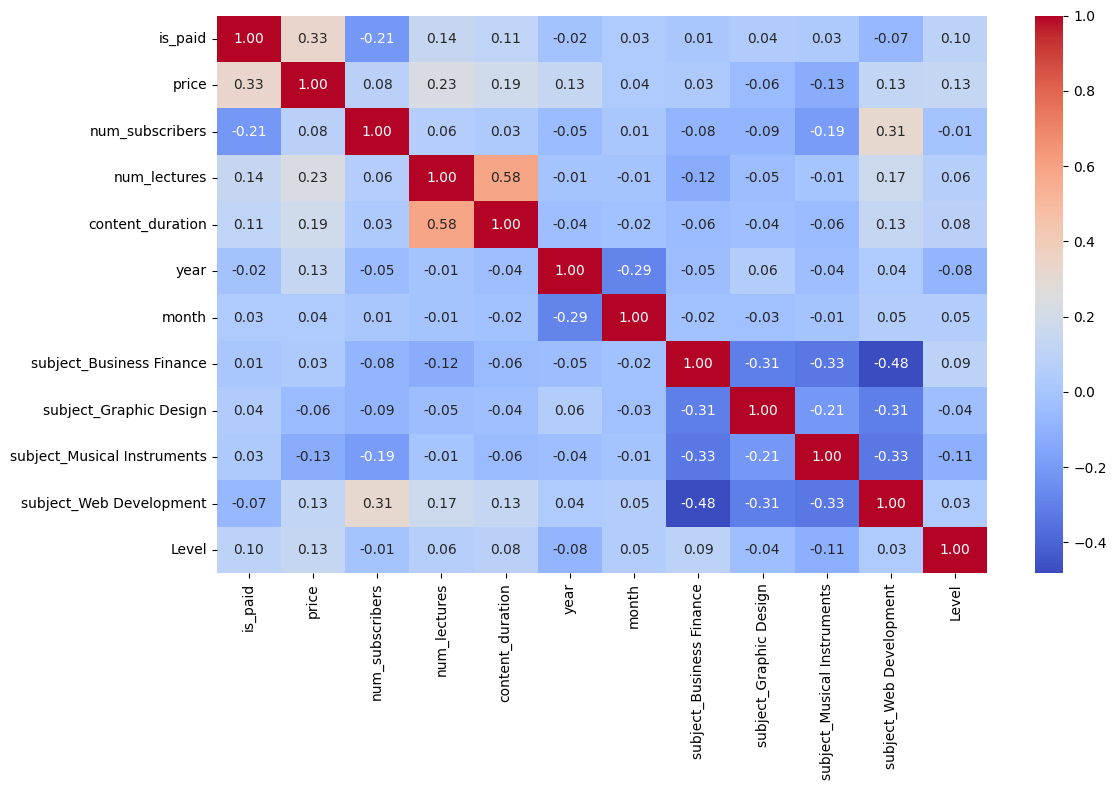

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

corr = courses.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})

#plt.xticks(rotation=40)
plt.tight_layout()

plt.show()


# visualization

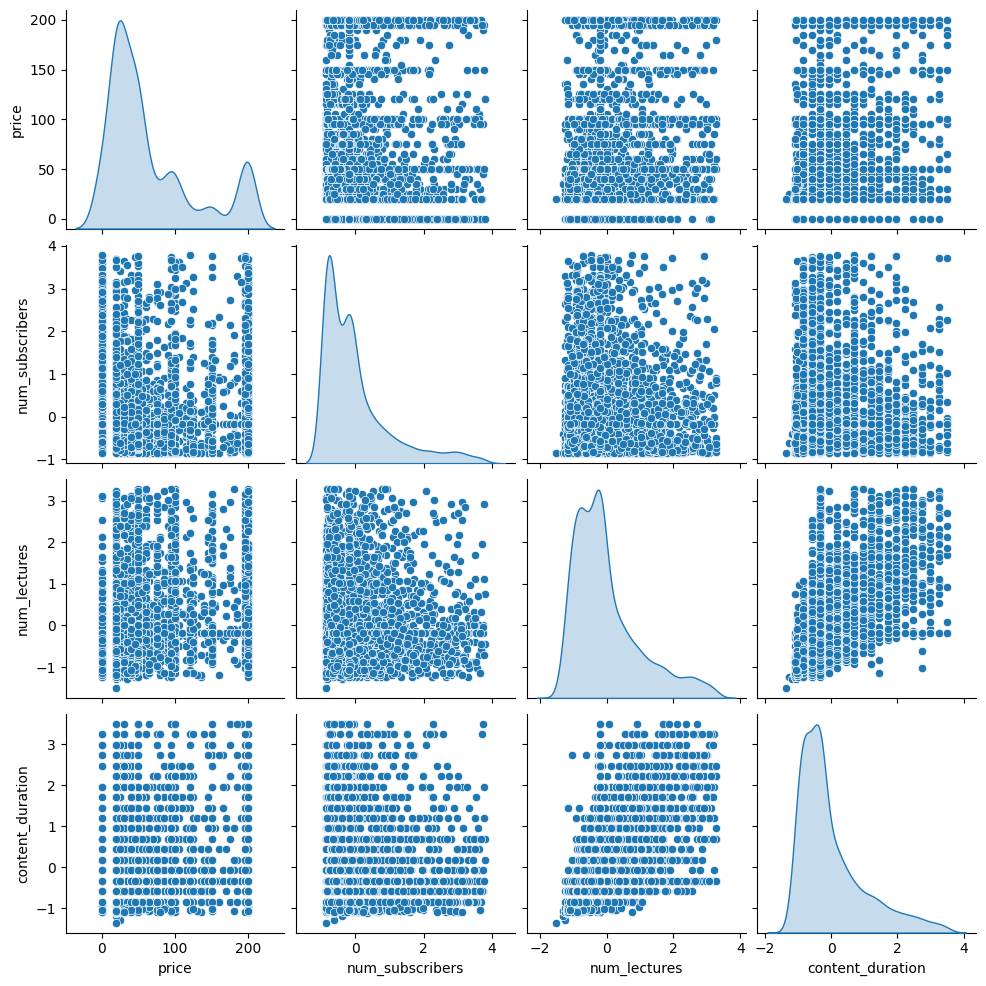

In [ ]:
import seaborn as sns
sns.pairplot(courses[['price', 'num_subscribers', 'num_lectures', 'content_duration']], diag_kind='kde')
plt.show()


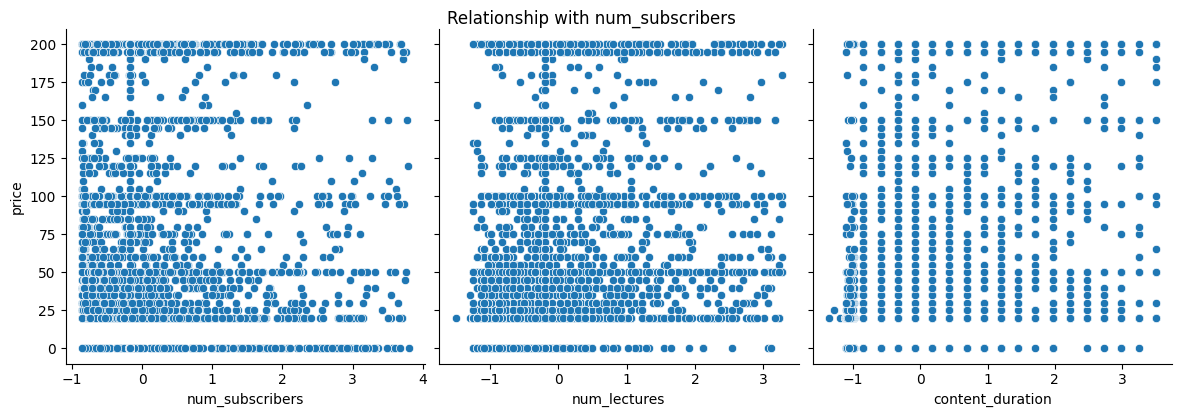

In [ ]:
sns.pairplot(
    data=courses[['price', 'num_lectures', 'content_duration', 'num_subscribers']],
    y_vars=['price'],
    x_vars=['num_subscribers', 'num_lectures', 'content_duration'],
    kind='scatter',
    height=4
)
plt.suptitle("Relationship with num_subscribers", y=1.02)
plt.show()


# Models regression

In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3678 entries, 0 to 3677
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   is_paid                      3678 non-null   int64  
 1   price                        3678 non-null   int64  
 2   num_subscribers              3678 non-null   float64
 3   num_lectures                 3678 non-null   float64
 4   content_duration             3678 non-null   float64
 5   year                         3678 non-null   int32  
 6   month                        3678 non-null   int32  
 7   subject_Business Finance     3678 non-null   float64
 8   subject_Graphic Design       3678 non-null   float64
 9   subject_Musical Instruments  3678 non-null   float64
 10  subject_Web Development      3678 non-null   float64
 11  Level                        3678 non-null   int64  
dtypes: float64(7), int32(2), int64(3)
memory usage: 316.2 KB


In [ ]:
results = []

In [ ]:
courses['price'].value_counts()

,count
price,
20,830
50,468
0,310
200,295
40,217
30,166
25,154
95,152
100,133


In [ ]:
courses['price'] = np.log1p(courses['price'])


In [ ]:
from sklearn.model_selection import train_test_split

X=courses.drop('price',axis=1)
Y=courses['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
x_train,x_test,y_train,y_test = train_test_split(X_scaled,Y,test_size=0.2,random_state=42)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()
# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'LinearRegression',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")


MAE: 0.57
MSE: 0.49
RMSE: 0.7
R2 Score: 0.748


In [ ]:
from sklearn.svm import SVR

kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:
    model = SVR(kernel=kernel)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': f'SVR_{kernel}',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })

    print(f"----- SVR with kernel = {kernel} -----")
    print(f"MAE: {round(mae, 2)}")
    print(f"MSE: {round(mse, 2)}")
    print(f"RMSE: {round(rmse, 2)}")
    print(f"R2 Score: {round(r2, 3)}\n")


----- SVR with kernel = linear -----
MAE: 0.57
MSE: 0.51
RMSE: 0.71
R2 Score: 0.74

----- SVR with kernel = poly -----
MAE: 0.54
MSE: 0.49
RMSE: 0.7
R2 Score: 0.746

----- SVR with kernel = rbf -----
MAE: 0.53
MSE: 0.48
RMSE: 0.7
R2 Score: 0.751



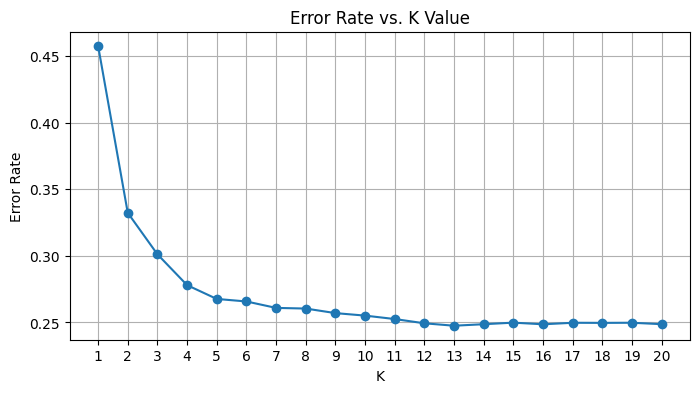

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

errors = []
k_range = range(1, 21)
for k in k_range:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    preds = model.predict(x_test)
    r2 = r2_score(y_test, preds)
    errors.append(1 - r2)

plt.figure(figsize=(8,4))
plt.plot(k_range, errors, marker='o')
plt.xticks(k_range)
plt.title("Error Rate vs. K Value")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.grid()
plt.show()

In [ ]:
model = KNeighborsRegressor(n_neighbors=7)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'KNeighborsRegressor',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")


MAE: 0.54
MSE: 0.51
RMSE: 0.71
R2 Score: 0.739


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42,max_depth=4)
# Train
model.fit(x_train, y_train)

# Predict
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'RandomForestRegressor',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")


MAE: 0.55
MSE: 0.47
RMSE: 0.69
R2 Score: 0.757


In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'XGBRegressor',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")


MAE: 0.53
MSE: 0.49
RMSE: 0.7
R2 Score: 0.75


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=72,random_state=42,max_depth=4)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'GradientBoostingRegressor',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")


MAE: 0.52
MSE: 0.44
RMSE: 0.66
R2 Score: 0.775


In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

base_models = [
    ('rf', RandomForestRegressor(n_estimators=72, random_state=42)),
    ('svr', SVR(kernel='rbf')),
    ('dt', DecisionTreeRegressor(random_state=42))
]
meta_model = LinearRegression()
model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model
)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
results.append({
        'Model': 'StackingRegressor',
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 3)
    })
print(f"MAE: {round(mae, 2)}")
print(f"MSE: {round(mse, 2)}")
print(f"RMSE: {round(rmse, 2)}")
print(f"R2 Score: {round(r2, 3)}")

MAE: 0.52
MSE: 0.45
RMSE: 0.67
R2 Score: 0.768


In [ ]:

results_df = pd.DataFrame(results)
print(results_df)


                       Model   MAE   MSE  RMSE  R2 Score
0           LinearRegression  0.57  0.49  0.70     0.748
1                 SVR_linear  0.57  0.51  0.71     0.740
2                   SVR_poly  0.54  0.49  0.70     0.746
3                    SVR_rbf  0.53  0.48  0.70     0.751
4        KNeighborsRegressor  0.54  0.51  0.71     0.739
5      RandomForestRegressor  0.55  0.47  0.69     0.757
6               XGBRegressor  0.53  0.49  0.70     0.750
7  GradientBoostingRegressor  0.52  0.44  0.66     0.775
8          StackingRegressor  0.52  0.45  0.67     0.768


/tmp/ipython-input-3474058584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


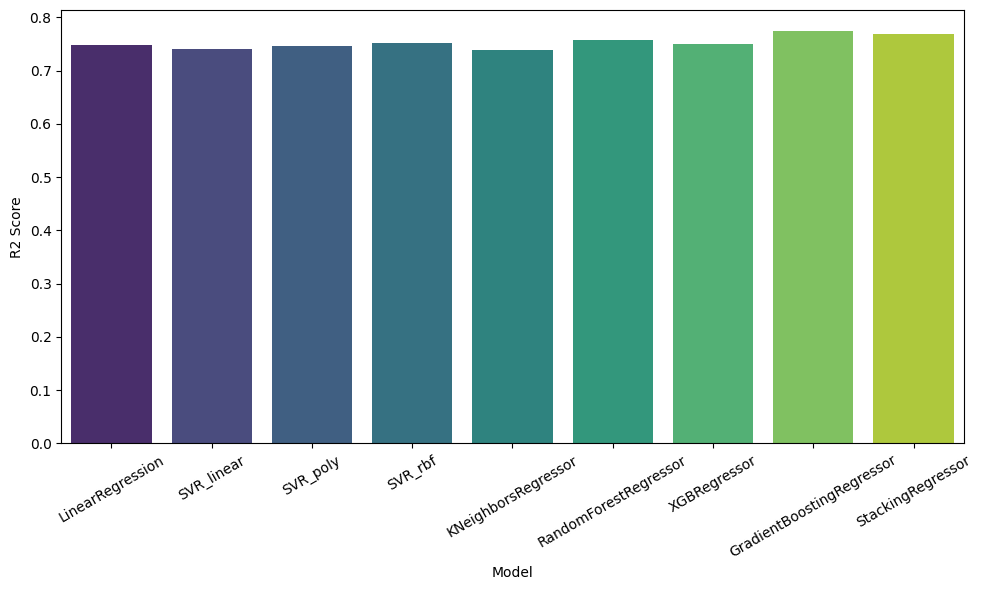

In [ ]:

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.ylabel('R2 Score')
plt.xlabel('Model')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# clustering

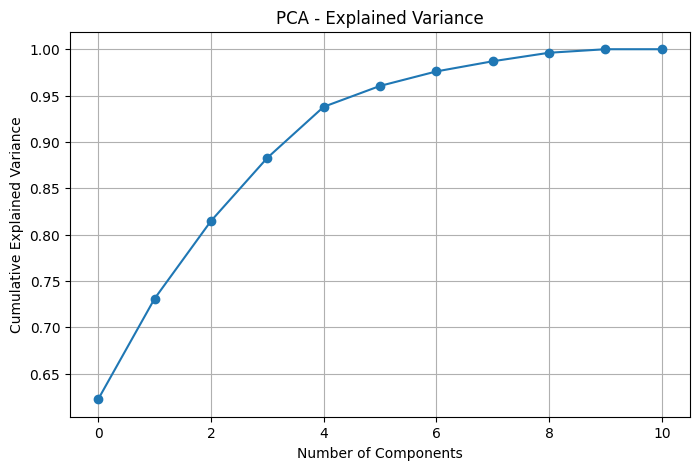

In [ ]:
from sklearn.decomposition import PCA
X = courses.drop(['price'], axis=1)
pca = PCA()
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid()
plt.show()


In [ ]:
pca = PCA(n_components=4)
X_reduced = pca.fit_transform(X)


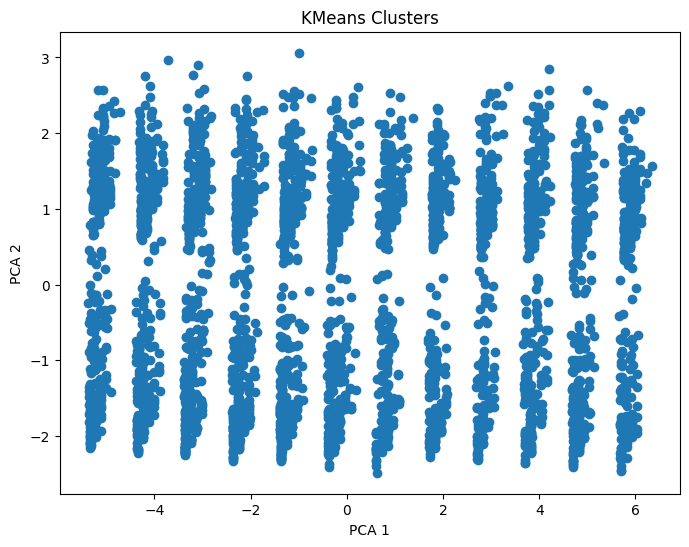

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title('KMeans Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

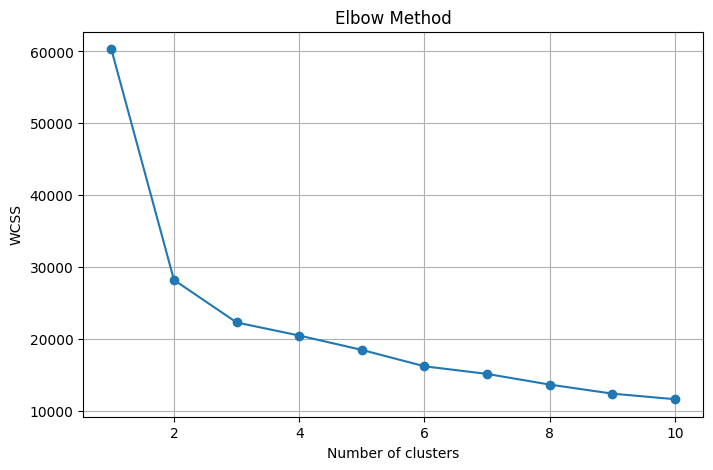

In [ ]:
from sklearn.cluster import KMeans
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_reduced)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid()
plt.show()


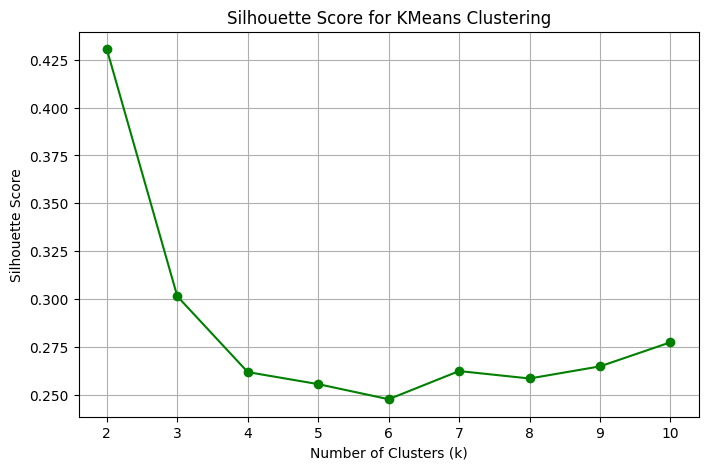

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score for KMeans Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid()
plt.show()


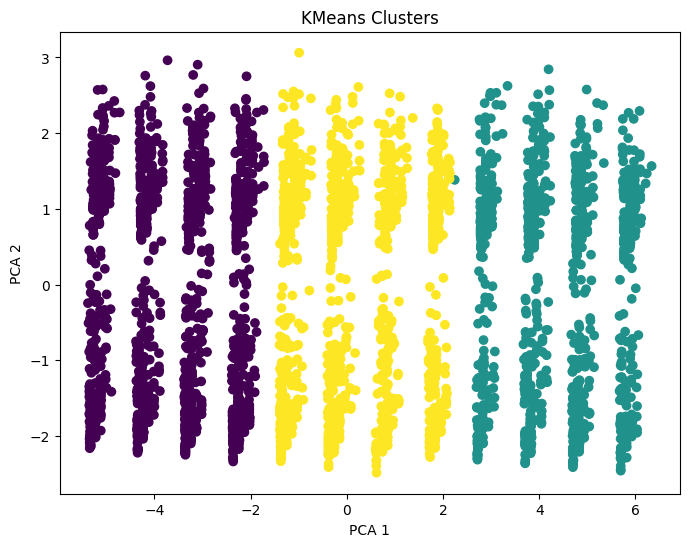

Silhouette Score for KMeans: 0.30148637570381887


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_reduced)

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_kmeans, cmap='viridis')
plt.title('KMeans Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()
score = silhouette_score(X_reduced, labels_kmeans)
print("Silhouette Score for KMeans:", score)

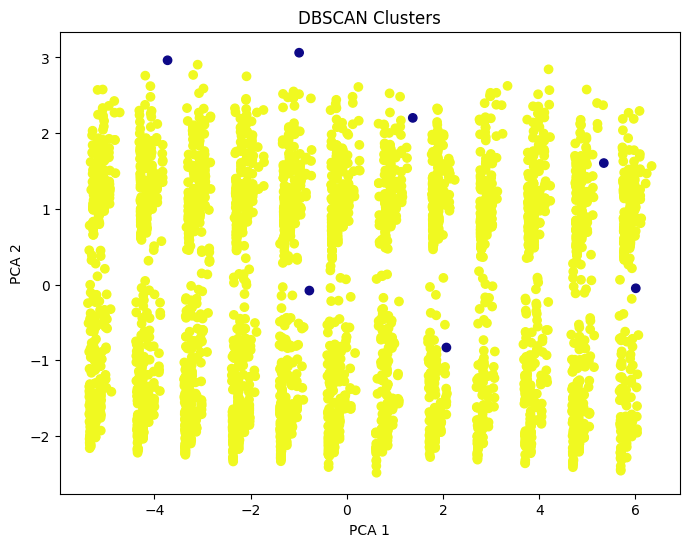

Silhouette Score for DBSCAN: 0.2119149174472379


In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=1.4, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_reduced)

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels_dbscan, cmap='plasma')
plt.title('DBSCAN Clusters')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()
score = silhouette_score(X_reduced, labels_dbscan)
print("Silhouette Score for DBSCAN:", score)
